# Predicción de Gravedad de Siniestros Viales
**RAPIDS cuML 24.04 + XGBoost GPU**

- **Dataset:** `Amenazas_Policía_Nacional_de_Colombia_20260202.csv`
- **Objetivo:** Clasificar `GRAVEDAD_ACCIDENTE` → `0` (CON HERIDOS) | `1` (CON MUERTOS)
- **Estrategias de desbalanceo:** SMOTE vs Class Weighting
- **Modelos:** XGBoost (GPU), Random Forest (cuML), Logistic Regression (cuML), KNN (cuML)

## 0. Imports y configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# RAPIDS / cuML
import cudf
import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLR
from cuml.neighbors import KNeighborsClassifier as cuKNN

# XGBoost GPU
import xgboost as xgb

# Imbalanced-learn (CPU – SMOTE requiere NumPy)
from imblearn.over_sampling import SMOTE

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, f1_score, precision_score, accuracy_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

# LIME
import lime
import lime.lime_tabular

# Target Encoding
from category_encoders import TargetEncoder

# Directorio de salida para gráficas
OUTPUT_DIR = Path("graficas_siniestros")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Entorno listo ✔")
print(f"  cudf  : {cudf.__version__}")
print(f"  cupy  : {cp.__version__}")
print(f"  xgb   : {xgb.__version__}")

Entorno listo ✔
  cudf  : 24.04.01
  cupy  : 13.6.0
  xgb   : 2.0.3


## 1. Carga del dataset

In [4]:
CSV_PATH = "VEHICULOS_INVOLUCRADOS_EN_UN_ACCIDENTE_DE_TRANSITO_LEY_2251-2022_20260205.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Filas originales : {len(df):,}")
print(f"Columnas         : {df.shape[1]}")
df.head(3)

Filas originales : 406,540
Columnas         : 9


,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


## 2. Limpieza básica

In [6]:
# Datetime
df["FECHA_ACCIDENTE"] = pd.to_datetime(df["FECHA_ACCIDENTE"], errors="coerce")

df["EDAD_VEHICULO"]   = pd.to_numeric(df["EDAD_VEHICULO"],   errors="coerce")
df["MODELO_VEHICULO"] = pd.to_numeric(df["MODELO_VEHICULO"], errors="coerce")

# Filtros de valores atípicos
df = df[
    df["MODELO_VEHICULO"].between(1950, 2025, inclusive="both") &
    (df["EDAD_VEHICULO"] <= 60)
].copy()

# Imputación de nulos
df["MARCA_VEHICULO"] = df["MARCA_VEHICULO"].fillna("Sin información")

mediana_edad = df.groupby("TIPO_VEHICULO")["EDAD_VEHICULO"].transform("median")
df["EDAD_VEHICULO"] = df["EDAD_VEHICULO"].fillna(mediana_edad)
df["EDAD_VEHICULO"] = df["EDAD_VEHICULO"].fillna(df["EDAD_VEHICULO"].median())

print(f"Filas tras limpieza: {len(df):,}")
print(f"Nulos restantes en columnas clave:")
print(df[["FECHA_ACCIDENTE", "MARCA_VEHICULO", "EDAD_VEHICULO", "MODELO_VEHICULO"]].isnull().sum())

Filas tras limpieza: 403,106
Nulos restantes en columnas clave:
FECHA_ACCIDENTE    0
MARCA_VEHICULO     0
EDAD_VEHICULO      0
MODELO_VEHICULO    0
dtype: int64


## 3. Ingeniería de características

In [7]:
df["AÑO"]        = df["FECHA_ACCIDENTE"].dt.year
df["MES"]        = df["FECHA_ACCIDENTE"].dt.month
df["DIA_SEMANA"] = df["FECHA_ACCIDENTE"].dt.dayofweek   # 0=Lunes … 6=Domingo
df["TRIMESTRE"]  = df["FECHA_ACCIDENTE"].dt.quarter
df["SEMESTRE"]   = (df["MES"] > 6).astype(int) + 1

df["MODELO_ESPECIFICO"] = (
    df["MARCA_VEHICULO"].astype(str) + "_" +
    df["MODELO_VEHICULO"].astype(str)
)

df["ANTIGÜEDAD_VEHICULO"] = df["AÑO"] - df["MODELO_VEHICULO"]

bins   = [-np.inf, 5, 10, 20, np.inf]
labels = ["0-5 años", "6-10 años", "11-20 años", ">20 años"]
df["CAT_EDAD_VEHICULO"] = pd.cut(
    df["ANTIGÜEDAD_VEHICULO"], bins=bins, labels=labels
).astype(str)

df["ES_VACACIONES"]      = df["MES"].isin([1, 6, 7, 12]).astype(int)
df["ES_MES_ALTO_RIESGO"] = df["MES"].isin([7, 9, 3, 5]).astype(int)

print("Features creadas ✔")
df[["MODELO_ESPECIFICO", "CAT_EDAD_VEHICULO", "ANTIGÜEDAD_VEHICULO",
    "ES_VACACIONES", "ES_MES_ALTO_RIESGO", "TRIMESTRE", "DIA_SEMANA"]].head(3)

Features creadas ✔


,MODELO_ESPECIFICO,CAT_EDAD_VEHICULO,ANTIGÜEDAD_VEHICULO,ES_VACACIONES,ES_MES_ALTO_RIESGO,TRIMESTRE,DIA_SEMANA
0,HONDA_2017,6-10 años,8,1,0,4,0
1,CHEVROLET_2007,11-20 años,18,1,0,4,0
2,JEEP_2017,6-10 años,8,1,0,4,0


## 4. Variable objetivo y selección de features

In [8]:
# Filtrar solo las dos clases válidas y crear TARGET
df = df[df["GRAVEDAD_ACCIDENTE"].isin(["CON HERIDOS", "CON MUERTOS"])].copy()
df["TARGET"] = (df["GRAVEDAD_ACCIDENTE"] == "CON MUERTOS").astype(int)

print("Distribución de TARGET:")
print(df["TARGET"].value_counts())
print(f"\nDesbalanceo: {df['TARGET'].value_counts(normalize=True).mul(100).round(2).to_string()}%")

FEATURES = [
    "TIPO_VEHICULO",
    "MODELO_ESPECIFICO",
    "CAT_EDAD_VEHICULO",
    "DEPARTAMENTO_ACCIDENTE",
    "TRIMESTRE",
    "ES_VACACIONES",
    "DIA_SEMANA",
]

X = df[FEATURES].copy()
y = df["TARGET"].copy()

# Rellenar nulos residuales en categóricas
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].fillna("Sin información")

print(f"\nFeatures seleccionadas ({len(FEATURES)}): {FEATURES}")

Distribución de TARGET:
TARGET
0    382750
1     20356
Name: count, dtype: int64

Desbalanceo: TARGET
0    94.95
1     5.05%

Features seleccionadas (7): ['TIPO_VEHICULO', 'MODELO_ESPECIFICO', 'CAT_EDAD_VEHICULO', 'DEPARTAMENTO_ACCIDENTE', 'TRIMESTRE', 'ES_VACACIONES', 'DIA_SEMANA']


## 5. Split estratificado y Target Encoding

In [9]:
CAT_COLS = ["TIPO_VEHICULO", "MODELO_ESPECIFICO", "CAT_EDAD_VEHICULO",
            "DEPARTAMENTO_ACCIDENTE"]

# Split ANTES del encoding para evitar data-leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

encoder = TargetEncoder(cols=CAT_COLS, smoothing=10)
X_train_enc = encoder.fit_transform(X_train_raw, y_train)
X_test_enc  = encoder.transform(X_test_raw)

# float32 requerido por cuML
X_train_enc = X_train_enc.astype(np.float32)
X_test_enc  = X_test_enc.astype(np.float32)
y_train_np  = y_train.values.astype(np.int32)
y_test_np   = y_test.values.astype(np.int32)

FEATURE_NAMES = list(X_train_enc.columns)

print(f"Train : {X_train_enc.shape}  |  Test : {X_test_enc.shape}")
print(f"Features finales: {FEATURE_NAMES}")

Train : (322484, 7)  |  Test : (80622, 7)
Features finales: ['TIPO_VEHICULO', 'MODELO_ESPECIFICO', 'CAT_EDAD_VEHICULO', 'DEPARTAMENTO_ACCIDENTE', 'TRIMESTRE', 'ES_VACACIONES', 'DIA_SEMANA']


## 6. Manejo del desbalanceo
### 6a. Estrategia 1 — SMOTE (CPU → GPU)

In [10]:
smote = SMOTE(random_state=42, n_jobs=-1)
X_train_smote_np, y_train_smote_np = smote.fit_resample(
    X_train_enc.values, y_train_np
)
X_train_smote_np = X_train_smote_np.astype(np.float32)
y_train_smote_np = y_train_smote_np.astype(np.int32)

print(f"SMOTE — clases tras resampleo: {np.bincount(y_train_smote_np)}")
print(f"  0 (CON HERIDOS): {np.bincount(y_train_smote_np)[0]:,}")
print(f"  1 (CON MUERTOS): {np.bincount(y_train_smote_np)[1]:,}")

SMOTE — clases tras resampleo: [306199 306199]
  0 (CON HERIDOS): 306,199
  1 (CON MUERTOS): 306,199


### 6b. Estrategia 2 — Class Weighting

In [11]:
classes = np.array([0, 1])
cw = compute_class_weight("balanced", classes=classes, y=y_train_np)
class_weight_dict = {0: cw[0], 1: cw[1]}
scale_pos_weight  = cw[1] / cw[0]

print(f"Class weights    : {class_weight_dict}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}  (usado en XGBoost)")

Class weights    : {0: 0.5265921835146424, 1: 9.901258827141541}
scale_pos_weight : 18.8025  (usado en XGBoost)


### 6c. Convertir a GPU (cuDF)

In [12]:
# Arrays originales → GPU
X_train_gpu = cudf.DataFrame.from_pandas(
    pd.DataFrame(X_train_enc.values, columns=FEATURE_NAMES)
)
X_test_gpu = cudf.DataFrame.from_pandas(
    pd.DataFrame(X_test_enc.values, columns=FEATURE_NAMES)
)
y_train_gpu = cudf.Series(y_train_np)
y_test_gpu  = cudf.Series(y_test_np)

# Arrays SMOTE → GPU
X_train_smote_gpu = cudf.DataFrame(X_train_smote_np, columns=FEATURE_NAMES)
y_train_smote_gpu = cudf.Series(y_train_smote_np)

print("Datos en GPU ✔")
print(f"  X_train_gpu      : {X_train_gpu.shape}")
print(f"  X_train_smote_gpu: {X_train_smote_gpu.shape}")

Datos en GPU ✔
  X_train_gpu      : (322484, 7)
  X_train_smote_gpu: (612398, 7)


## 7. Definición de funciones auxiliares

In [13]:
def gmean(y_true, y_pred):
    """Media geométrica de sensibilidad y especificidad."""
    recall_pos = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_neg = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return np.sqrt(recall_pos * recall_neg)


def evaluate(model, X_test, y_true_np, model_name, strategy):
    """Calcula todas las métricas y devuelve un dict."""
    if isinstance(X_test, cudf.DataFrame):
        y_pred_raw = model.predict(X_test)
        y_pred = (y_pred_raw.to_numpy() if hasattr(y_pred_raw, "to_numpy")
                  else np.array(y_pred_raw)).astype(int)
        try:
            y_prob_raw = model.predict_proba(X_test)
            y_prob = (y_prob_raw.to_numpy() if hasattr(y_prob_raw, "to_numpy")
                      else np.array(y_prob_raw))[:, 1]
        except Exception:
            y_prob = y_pred.astype(float)
    else:
        y_pred = model.predict(X_test).astype(int)
        y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Modelo"    : model_name,
        "Estrategia": strategy,
        "Recall"    : recall_score(y_true_np, y_pred, pos_label=1, zero_division=0),
        "Precision" : precision_score(y_true_np, y_pred, pos_label=1, zero_division=0),
        "F1-Macro"  : f1_score(y_true_np, y_pred, average="macro", zero_division=0),
        "G-Mean"    : gmean(y_true_np, y_pred),
        "Accuracy"  : accuracy_score(y_true_np, y_pred),
        "ROC-AUC"   : roc_auc_score(y_true_np, y_prob),
        "_y_pred"   : y_pred,
        "_y_prob"   : y_prob,
    }


def save_show(fig, filename):
    """Guarda PNG y muestra la figura."""
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Guardada: {path}")
    plt.show()
    plt.close(fig)


PALETTE = {
    "XGBoost"           : "#E07B39",
    "RandomForest"      : "#3D7EAA",
    "LogisticRegression": "#5BA85F",
    "KNN"               : "#A259A4",
}

print("Funciones auxiliares definidas ✔")

Funciones auxiliares definidas ✔


## 8. Entrenamiento de modelos
### 8a. Estrategia SMOTE

In [14]:
all_results    = []
trained_models = {}

strategy_name = "SMOTE"
X_tr_np  = X_train_smote_np
y_tr_np  = y_train_smote_np
X_tr_gpu = X_train_smote_gpu
y_tr_gpu = y_train_smote_gpu

models_smote = {
    "XGBoost": xgb.XGBClassifier(
        tree_method="hist", device="cuda",
        eval_metric="logloss", use_label_encoder=False,
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
    ),
    "RandomForest": cuRF(
        n_estimators=300, max_depth=16, max_features=0.5,
        n_streams=4, random_state=42,
    ),
    "LogisticRegression": cuLR(max_iter=1000, C=1.0, solver="qn"),
    "KNN": cuKNN(n_neighbors=7, metric="euclidean"),
}

for model_name, model in models_smote.items():
    print(f"  Entrenando {model_name} [{strategy_name}]...", end=" ", flush=True)
    if model_name == "XGBoost":
        model.fit(
            X_tr_np, y_tr_np,
            eval_set=[(X_test_enc.values.astype(np.float32), y_test_np)],
            verbose=False,
        )
        res = evaluate(model, X_test_enc.values.astype(np.float32),
                       y_test_np, model_name, strategy_name)
    else:
        model.fit(X_tr_gpu, y_tr_gpu)
        res = evaluate(model, X_test_gpu, y_test_np, model_name, strategy_name)

    trained_models[(model_name, strategy_name)] = model
    all_results.append(res)
    print(f"Recall={res['Recall']:.4f}  F1={res['F1-Macro']:.4f}  AUC={res['ROC-AUC']:.4f}")

  Entrenando XGBoost [SMOTE]... Recall=0.2537  F1=0.5863  AUC=0.7368
  Entrenando RandomForest [SMOTE]... Recall=0.3117  F1=0.5708  AUC=0.7176
  Entrenando LogisticRegression [SMOTE]... Recall=0.5986  F1=0.5515  AUC=0.7680
  Entrenando KNN [SMOTE]... Recall=0.3260  F1=0.5614  AUC=0.6689


### 8b. Estrategia Class Weighting

In [15]:
strategy_name = "Class Weighting"
X_tr_np  = X_train_enc.values.astype(np.float32)
y_tr_np  = y_train_np
X_tr_gpu = X_train_gpu
y_tr_gpu = y_train_gpu

models_weight = {
    "XGBoost": xgb.XGBClassifier(
        tree_method="hist", device="cuda",
        eval_metric="logloss", use_label_encoder=False,
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        scale_pos_weight=scale_pos_weight,
    ),
    "RandomForest": cuRF(
        n_estimators=300, max_depth=16, max_features=0.5,
        n_streams=4, random_state=42,
    ),
    "LogisticRegression": cuLR(max_iter=1000, C=1.0, solver="qn"),
    "KNN": cuKNN(n_neighbors=7, metric="euclidean"),
}

for model_name, model in models_weight.items():
    print(f"  Entrenando {model_name} [{strategy_name}]...", end=" ", flush=True)
    if model_name == "XGBoost":
        model.fit(
            X_tr_np, y_tr_np,
            eval_set=[(X_test_enc.values.astype(np.float32), y_test_np)],
            verbose=False,
        )
        res = evaluate(model, X_test_enc.values.astype(np.float32),
                       y_test_np, model_name, strategy_name)
    else:
        model.fit(X_tr_gpu, y_tr_gpu)
        res = evaluate(model, X_test_gpu, y_test_np, model_name, strategy_name)

    trained_models[(model_name, strategy_name)] = model
    all_results.append(res)
    print(f"Recall={res['Recall']:.4f}  F1={res['F1-Macro']:.4f}  AUC={res['ROC-AUC']:.4f}")

  Entrenando XGBoost [Class Weighting]... Recall=0.6662  F1=0.5205  AUC=0.7692
  Entrenando RandomForest [Class Weighting]... Recall=0.0310  F1=0.5148  AUC=0.7461
  Entrenando LogisticRegression [Class Weighting]... [W] [22:02:02.201239] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
Recall=0.0287  F1=0.5130  AUC=0.7689
  Entrenando KNN [Class Weighting]... Recall=0.0351  F1=0.5176  AUC=0.6446


## 9. Matrices de Confusión

Guardada: graficas_siniestros/01_matrices_confusion.png


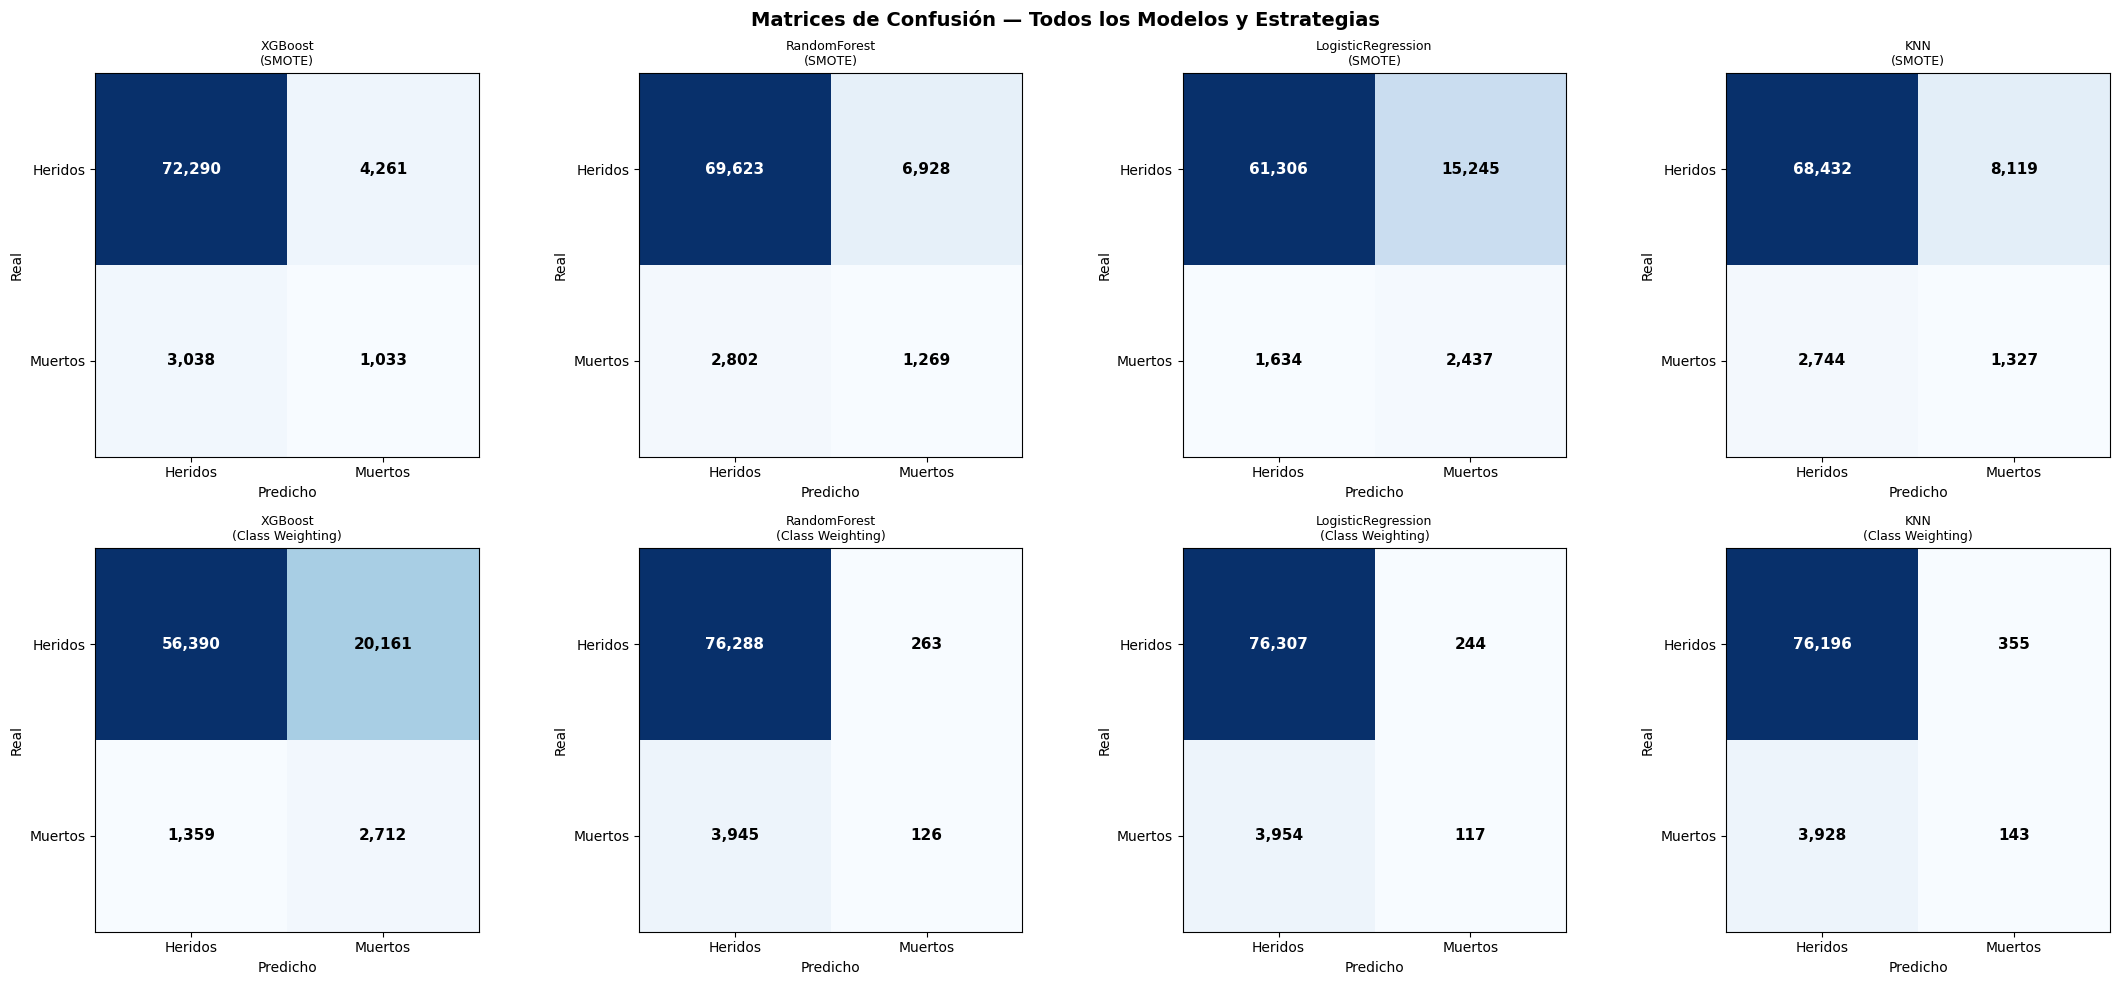

In [16]:
model_names    = ["XGBoost", "RandomForest", "LogisticRegression", "KNN"]
strategy_names = ["SMOTE", "Class Weighting"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Matrices de Confusión — Todos los Modelos y Estrategias",
             fontsize=14, fontweight="bold")

for row_idx, strategy in enumerate(strategy_names):
    for col_idx, mname in enumerate(model_names):
        ax  = axes[row_idx][col_idx]
        res = next(r for r in all_results
                   if r["Modelo"] == mname and r["Estrategia"] == strategy)
        cm  = confusion_matrix(y_test_np, res["_y_pred"])
        ax.imshow(cm, cmap="Blues")
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(["Heridos", "Muertos"])
        ax.set_yticklabels(["Heridos", "Muertos"])
        ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
        ax.set_title(f"{mname}\n({strategy})", fontsize=9)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i,j]:,}",
                        ha="center", va="center",
                        color="white" if cm[i,j] > cm.max()/2 else "black",
                        fontsize=11, fontweight="bold")

plt.tight_layout()
save_show(fig, "01_matrices_confusion.png")

## 10. Curvas ROC

Guardada: graficas_siniestros/02_curvas_roc.png


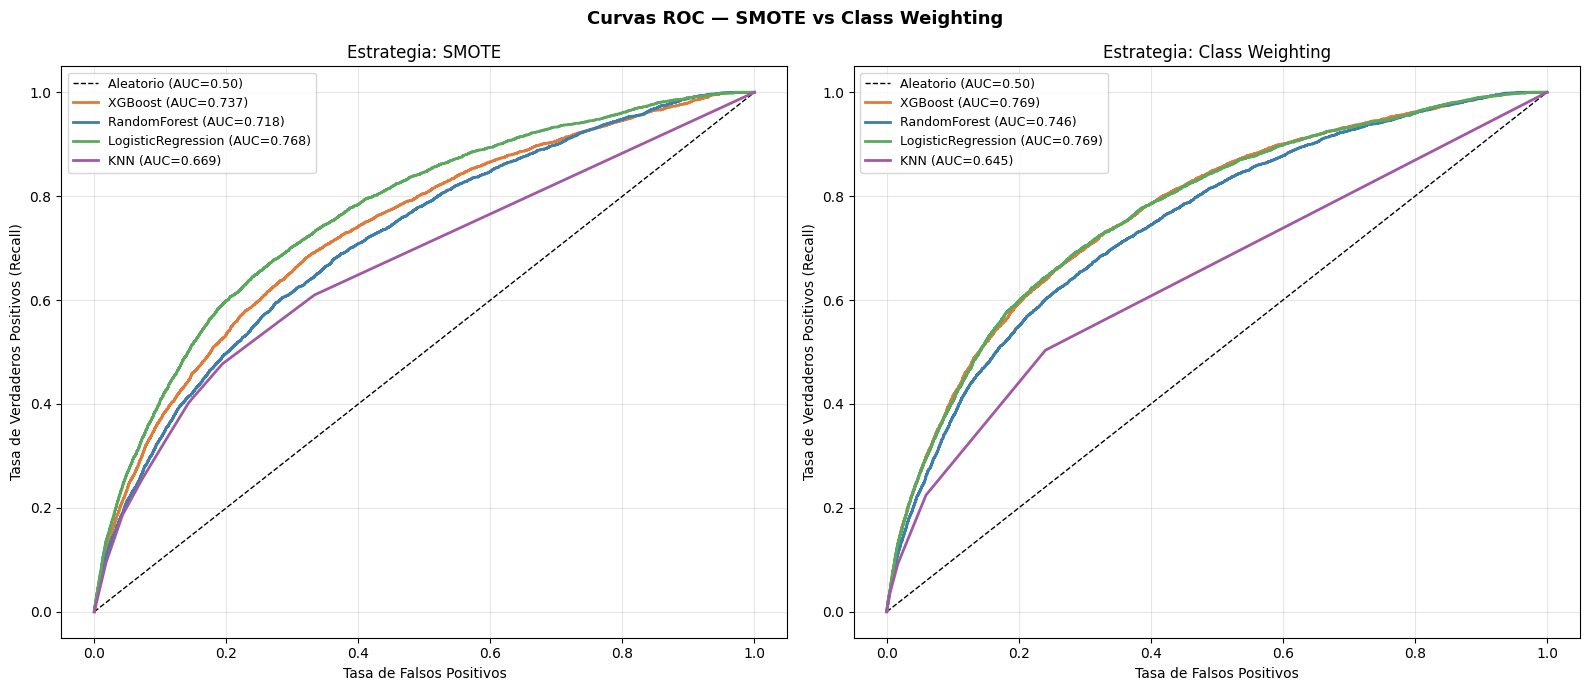

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Curvas ROC — SMOTE vs Class Weighting",
             fontsize=13, fontweight="bold")

for col_idx, strategy in enumerate(strategy_names):
    ax = axes[col_idx]
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio (AUC=0.50)")
    for mname in model_names:
        res = next(r for r in all_results
                   if r["Modelo"] == mname and r["Estrategia"] == strategy)
        fpr, tpr, _ = roc_curve(y_test_np, res["_y_prob"])
        ax.plot(fpr, tpr, color=PALETTE[mname], lw=2,
                label=f"{mname} (AUC={res['ROC-AUC']:.3f})")
    ax.set_xlabel("Tasa de Falsos Positivos")
    ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
    ax.set_title(f"Estrategia: {strategy}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
save_show(fig, "02_curvas_roc.png")

## 11. Feature Importances — XGBoost

Guardada: graficas_siniestros/03_feature_importance_xgboost.png


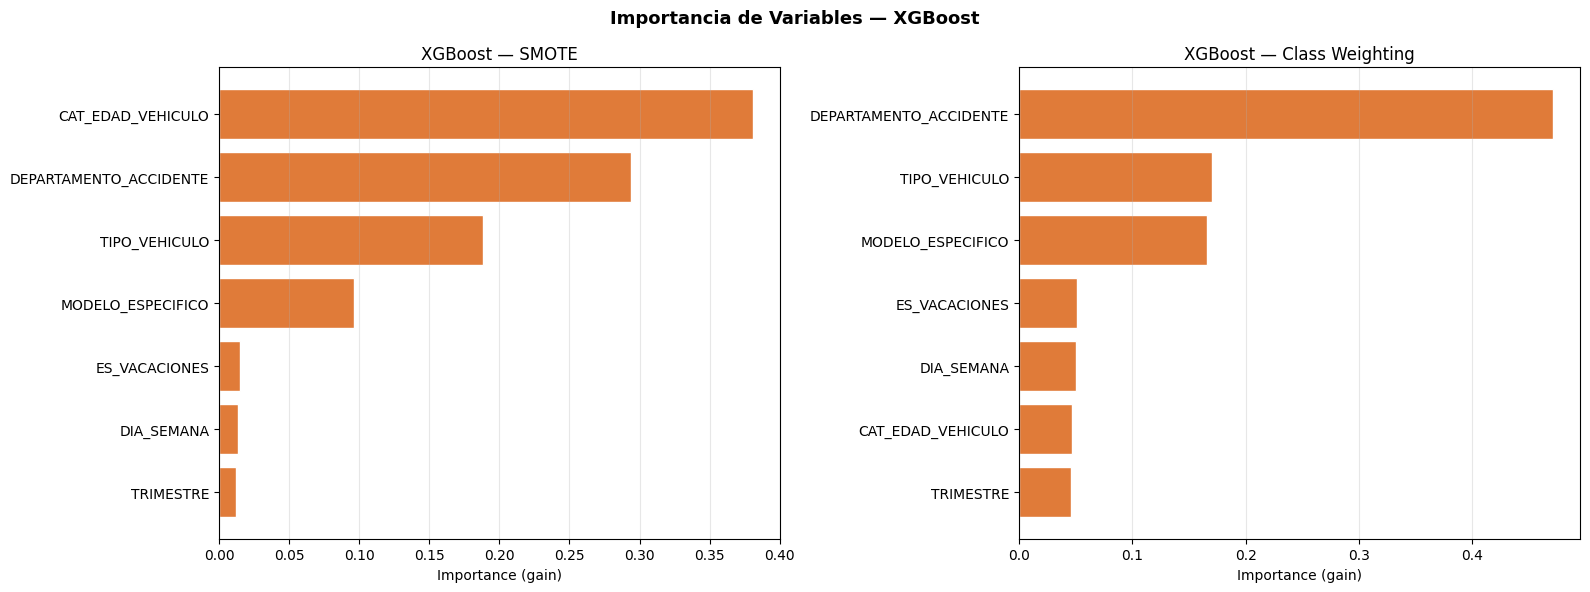

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Importancia de Variables — XGBoost",
             fontsize=13, fontweight="bold")

for col_idx, strategy in enumerate(strategy_names):
    model       = trained_models[("XGBoost", strategy)]
    importances = model.feature_importances_
    idx         = np.argsort(importances)[::-1]
    ax          = axes[col_idx]
    ax.barh([FEATURE_NAMES[i] for i in idx], importances[idx],
            color="#E07B39", edgecolor="white")
    ax.set_xlabel("Importance (gain)")
    ax.set_title(f"XGBoost — {strategy}")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
save_show(fig, "03_feature_importance_xgboost.png")

## 12. Feature Importances — Random Forest

AttributeError: get_feature_importances

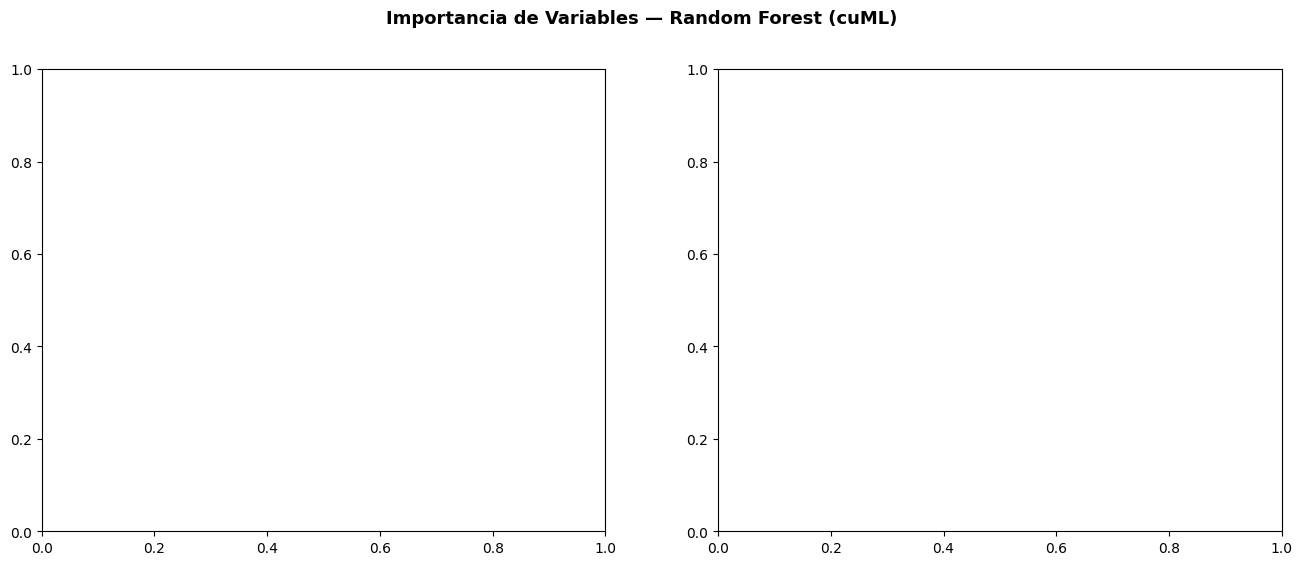

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Importancia de Variables — Random Forest (cuML)", fontsize=13, fontweight="bold")

for col_idx, strategy in enumerate(strategy_names):
    model = trained_models[("RandomForest", strategy)]
    
    # cuML RF expone importancias via get_feature_importances()
    importances = np.array(model.get_feature_importances())
    idx = np.argsort(importances)[::-1]
    ax = axes[col_idx]
    ax.barh([FEATURE_NAMES[i] for i in idx], importances[idx], color="#3D7EAA", edgecolor="white")
    ax.set_xlabel("Importance (impurity)")
    ax.set_title(f"Random Forest — {strategy}")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
save_show(fig, "04_feature_importance_rf.png")

In [24]:
model = trained_models[("RandomForest", "SMOTE")]
print([a for a in dir(model) if "import" in a.lower() or "feature" in a.lower()])

['_set_n_features_in', 'max_features', 'n_features_in_']


## 13. LIME — Interpretabilidad local del mejor modelo

In [25]:
# Seleccionar el mejor modelo por Recall (métrica prioritaria)
best_result = max(all_results, key=lambda r: r["Recall"])
best_key    = (best_result["Modelo"], best_result["Estrategia"])
best_model  = trained_models[best_key]

print(f"Mejor modelo : {best_key[0]}")
print(f"Estrategia   : {best_key[1]}")
print(f"Recall       : {best_result['Recall']:.4f}")

# Instancia fatal aleatoria del conjunto de prueba
fatal_idx  = np.where(y_test_np == 1)[0]
rng        = np.random.RandomState(42)
sample_idx = rng.choice(fatal_idx)
sample     = X_test_enc.values[sample_idx : sample_idx + 1].astype(np.float32)

print(f"\nInstancia analizada: índice #{sample_idx} (CON MUERTOS)")

Mejor modelo : XGBoost
Estrategia   : Class Weighting
Recall       : 0.6662

Instancia analizada: índice #63209 (CON MUERTOS)


Guardada: graficas_siniestros/05_lime_explicacion.png


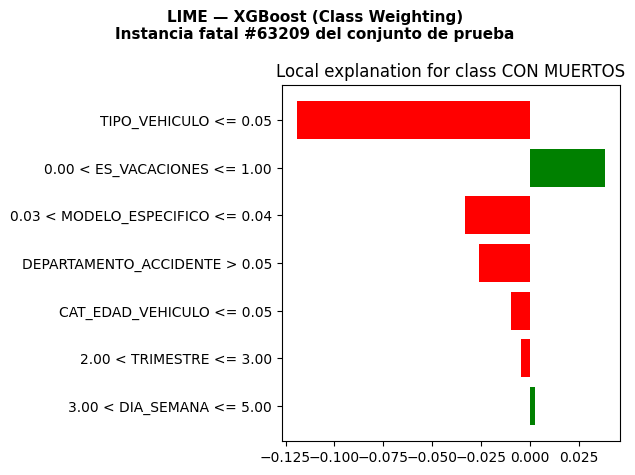

LIME HTML guardado: graficas_siniestros/05_lime_explicacion.html


In [26]:
def predict_proba_fn(X_np):
    """Wrapper para LIME: siempre recibe NumPy, devuelve NumPy."""
    X_np = X_np.astype(np.float32)
    if best_key[0] == "XGBoost":
        return best_model.predict_proba(X_np)
    else:
        X_cudf = cudf.DataFrame(X_np, columns=FEATURE_NAMES)
        proba  = best_model.predict_proba(X_cudf)
        return np.array(proba.to_numpy() if hasattr(proba, "to_numpy") else proba)


explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data        = X_train_enc.values.astype(np.float32),
    feature_names        = FEATURE_NAMES,
    class_names          = ["CON HERIDOS", "CON MUERTOS"],
    mode                 = "classification",
    discretize_continuous= True,
    random_state         = 42,
)

explanation = explainer.explain_instance(
    data_row  = sample[0],
    predict_fn= predict_proba_fn,
    num_features=len(FEATURE_NAMES),
    num_samples =5000,
)

fig_lime = explanation.as_pyplot_figure()
fig_lime.suptitle(
    f"LIME — {best_key[0]} ({best_key[1]})\n"
    f"Instancia fatal #{sample_idx} del conjunto de prueba",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
save_show(fig_lime, "05_lime_explicacion.png")

# Guardar también como HTML interactivo
html_path = OUTPUT_DIR / "05_lime_explicacion.html"
explanation.save_to_file(str(html_path))
print(f"LIME HTML guardado: {html_path}")

## 14. Tabla comparativa final de métricas

In [27]:
metric_cols = ["Recall", "Precision", "F1-Macro", "G-Mean", "Accuracy", "ROC-AUC"]

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in all_results
])
df_results = df_results.set_index(["Modelo", "Estrategia"])[metric_cols]

# Guardar como CSV
csv_path = OUTPUT_DIR / "metricas_comparativas.csv"
df_results.to_csv(csv_path)
print(f"CSV guardado en: {csv_path}\n")

# Mostrar tabla formateada
df_results.style \
    .format("{:.4f}") \
    .background_gradient(subset=["Recall"], cmap="Greens") \
    .background_gradient(subset=["ROC-AUC"], cmap="Blues") \
    .background_gradient(subset=["F1-Macro"], cmap="Oranges") \
    .set_caption("Tabla Comparativa de Métricas — Todos los Modelos y Estrategias")

CSV guardado en: graficas_siniestros/metricas_comparativas.csv



,,Recall,Precision,F1-Macro,G-Mean,Accuracy,ROC-AUC
Modelo,Estrategia,,,,,,
XGBoost,SMOTE,0.2537,0.1951,0.5863,0.4895,0.9095,0.7368
RandomForest,SMOTE,0.3117,0.1548,0.5708,0.5325,0.8793,0.7176
LogisticRegression,SMOTE,0.5986,0.1378,0.5515,0.6924,0.7906,0.7680
KNN,SMOTE,0.3260,0.1405,0.5614,0.5398,0.8653,0.6689
XGBoost,Class Weighting,0.6662,0.1186,0.5205,0.7005,0.7331,0.7692
RandomForest,Class Weighting,0.0310,0.3239,0.5148,0.1756,0.9478,0.7461
LogisticRegression,Class Weighting,0.0287,0.3241,0.5130,0.1693,0.9479,0.7689
KNN,Class Weighting,0.0351,0.2871,0.5176,0.1870,0.9469,0.6446


In [28]:
# Destacar el mejor modelo por Recall
best_row = df_results["Recall"].idxmax()
print("★  MEJOR MODELO POR RECALL")
print(f"   Modelo     : {best_row[0]}")
print(f"   Estrategia : {best_row[1]}")
print()
print(df_results.loc[best_row].to_string())

★  MEJOR MODELO POR RECALL
   Modelo     : XGBoost
   Estrategia : Class Weighting

Recall       0.666175
Precision    0.118568
F1-Macro     0.520534
G-Mean       0.700519
Accuracy     0.733075
ROC-AUC      0.769225
